# Chapter 5: Classical Simulation Methods

**Docker image**: `ml4t`

**Purpose**: Implement and compare classical Monte Carlo methods for generating
synthetic financial data, building the foundation for the learned generative
models that follow.

This notebook teaches the **mechanics** of established Monte Carlo methods for
generating synthetic financial data. We cover both the underlying mathematics
and practical implementation, then show library shortcuts for production use.

## Why Simulate?

Historical market data provides only **one path** through an infinite space of
possibilities. Simulation generates alternative scenarios for:

1. **Risk Management**: VaR, stress testing, tail risk assessment
2. **Backtesting**: Validate strategies beyond historical experience
3. **Data Augmentation**: Larger datasets for ML model training
4. **Privacy**: Share synthetic data without exposing proprietary signals

## Learning Objectives

After completing this notebook, you will be able to:

1. **Implement** each classical stochastic model from scratch
2. **Explain** the assumptions and limitations of each model
3. **Choose** the appropriate model for your use case
4. **Use** library implementations for production work

**Book Reference**: Chapter 5, Section 5.3 (Classical simulation baselines)

**Prerequisites**: Basic probability and stochastic processes; familiarity
with NumPy array operations. Requires ETF data from Chapter 2 (`load_etfs()`).

## Notebook Structure

1. **Part 1**: Continuous-Time Price Models (GBM, Jump-Diffusion, OU, Heston)
2. **Part 2**: Discrete-Time Volatility Model (GARCH with calibration)
3. **Part 3**: Bootstrap Methods (IID, Block, Stationary)
4. **Part 4**: Model Comparison

## Statistical Note

We use **log-returns** throughout for consistency with continuous-time SDEs:
- Log-return: $r_t = \ln(S_t / S_{t-1})$
- Kurtosis values are **Fisher (excess) kurtosis**: Gaussian = 0

## References

- Glasserman, P. (2003). "Monte Carlo Methods in Financial Engineering"
- Politis, D. & Romano, J. (1994). "The Stationary Bootstrap"
- Cont, R. (2001). "Empirical Properties of Asset Returns: Stylized Facts"
- Heston, S. (1993). "A Closed-Form Solution for Options with Stochastic Volatility"

In [1]:
"""Classical Simulation Methods - Educational implementation of stochastic models."""

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import polars as pl
import seaborn as sns
from arch import arch_model
from arch.bootstrap import IIDBootstrap, MovingBlockBootstrap, StationaryBootstrap
from ml4t.data.providers import SyntheticProvider
from plotly.subplots import make_subplots
from scipy.stats import kurtosis, norm, skew
from statsmodels.tsa.stattools import acf

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_plotly_with_alt, show_with_alt

In [2]:
SEED = 42
N_PATHS = 200
N_BOOTSTRAP_REPLICATES = 200

Every generator below is spawned from `SEED`, so overriding the parameter
moves every simulation in the notebook rather than only the ones that happen
to read a global. `STREAMS` names one independent stream per use, and
`stream()` hands out its generator.

In [3]:
set_global_seeds(SEED)

STREAMS = (
    "gbm",
    "jump_diffusion",
    "mean_reversion",
    "heston",
    "garch",
    "model_paths",
    "iid_bootstrap",
    "block_bootstrap",
    "stationary_bootstrap",
    "bootstrap_replicates",
)
_SEED_SEQUENCES = dict(zip(STREAMS, np.random.SeedSequence(SEED).spawn(len(STREAMS)), strict=True))


def stream(name: str) -> np.random.Generator:
    """Return the independent generator reserved for *name*."""
    return np.random.default_rng(_SEED_SEQUENCES[name])

---
# Part 1: Continuous-Time Price Models

These models specify stochastic differential equations (SDEs) for price dynamics.
Each captures different market phenomena:

| Model | Key Feature | Best For |
|-------|-------------|----------|
| **GBM** | Log-normal prices, constant vol | Option pricing, baseline |
| **Jump-Diffusion** | Rare extreme moves | Crash scenarios, tail risk |
| **Mean-Reversion** | Prices drift to equilibrium | Spreads, commodities, rates |
| **Heston** | Stochastic volatility | Vol surfaces, leverage effect |

We implement each from scratch using local RNG for reproducibility,
then show the equivalent library call.

## Geometric Brownian Motion

The foundation of quantitative finance. Price $S$ follows the stochastic
differential equation:

$$dS = \mu S \, dt + \sigma S \, dW$$

where:
- $\mu$ = drift (expected annual return)
- $\sigma$ = volatility (annualized)
- $dW$ = Wiener process increment (Brownian motion)

### Key Properties

- **Log-returns are Gaussian**: $\ln(S_{t+1}/S_t) \sim N((\mu - \sigma^2/2)\Delta t, \sigma^2 \Delta t)$
- **Prices are log-normal**: Always positive, no crashes below zero
- **No memory**: Future returns independent of past (no autocorrelation)
- **Constant volatility**: Same vol every day (unrealistic)

### Discretization (Euler-Maruyama)

$$S_{t+\Delta t} = S_t \exp\left((\mu - \frac{\sigma^2}{2}) \Delta t + \sigma \sqrt{\Delta t} \, Z\right)$$

where $Z \sim N(0,1)$.

In [4]:
def simulate_gbm(
    n_steps: int,
    mu: float,
    sigma: float,
    S0: float = 100.0,
    dt: float = 1 / 252,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """
    Generate Geometric Brownian Motion price path.

    Parameters
    ----------
    n_steps : int
        Number of time steps
    mu : float
        Annual drift (expected return)
    sigma : float
        Annual volatility
    S0 : float
        Initial price
    dt : float
        Time step (1/252 for daily)
    rng : np.random.Generator, optional
        Random number generator for reproducibility

    Returns
    -------
    np.ndarray
        Price path of length n_steps + 1
    """
    if rng is None:
        rng = np.random.default_rng()

    # Standard normal random draws
    Z = rng.standard_normal(n_steps)

    # Log-return for each step
    log_returns = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

    # Cumulative sum gives log-prices, then exponentiate
    log_prices = np.cumsum(log_returns)
    prices = S0 * np.exp(log_prices)

    # Prepend initial price
    return np.insert(prices, 0, S0)

### GBM Simulation

Generate two years of daily data (504 trading days) and inspect the return
distribution. Excess kurtosis should sit near zero: GBM's log-returns are
Gaussian by construction, and any departure is sampling noise from one path.

In [5]:
GBM_MU, GBM_SIGMA = 0.08, 0.20
N_STEPS = 504

gbm_prices = simulate_gbm(n_steps=N_STEPS, mu=GBM_MU, sigma=GBM_SIGMA, rng=stream("gbm"))
gbm_returns = np.diff(np.log(gbm_prices))

print(f"GBM simulation: {len(gbm_prices)} prices")
print(f"Annualized return: {gbm_returns.mean() * 252:.2%}")
print(f"Annualized volatility: {gbm_returns.std() * np.sqrt(252):.2%}")
print(f"Skewness: {skew(gbm_returns):.4f} (Gaussian: 0)")
print(f"Excess kurtosis: {kurtosis(gbm_returns, fisher=True, bias=False):.4f} (Gaussian: 0)")

GBM simulation: 505 prices
Annualized return: 9.42%
Annualized volatility: 19.25%
Skewness: -0.0557 (Gaussian: 0)
Excess kurtosis: 0.2133 (Gaussian: 0)


### Library Usage: GBM

`SyntheticProvider` in the `ml4t-data` package generates the same processes
behind an OHLCV interface. It draws from its own generator, so a provider path
never matches a from-scratch path step for step; what should agree is the
distribution the two draw from. GBM is the one model whose full parameter set
the provider exposes (`annual_return`, `annual_volatility`), so it is the one
case where the two are the same process and the realized moments are
comparable.

In [6]:
provider = SyntheticProvider(
    model="gbm", annual_return=GBM_MU, annual_volatility=GBM_SIGMA, seed=SEED
)
df = provider.fetch_ohlcv("SYNTH", "2022-01-01", "2023-12-31", "daily")
provider_gbm_returns = np.diff(np.log(df["close"].to_numpy()))

print(f"SyntheticProvider GBM: {len(df)} bars")
print(f"  realized annual volatility: {provider_gbm_returns.std() * np.sqrt(252):.3f}")
print(f"  from-scratch, same parameters: {gbm_returns.std() * np.sqrt(252):.3f}")
print(f"  requested: {GBM_SIGMA:.3f}")

2026-09-08 22:17:11 [debug    ] Rate limiter initialized       max_calls=1000 period=1.0 provider=synthetic


2026-09-08 22:17:11 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-09-08 22:17:11 [info     ] Fetching OHLCV data            end=2023-12-31 frequency=daily name=SyntheticProvider provider=synthetic start=2022-01-01 symbol=SYNTH


2026-09-08 22:17:11 [info     ] Generating 520 synthetic bars  frequency=daily model=gbm symbol=SYNTH


2026-09-08 22:17:11 [info     ] Successfully fetched OHLCV data name=SyntheticProvider provider=synthetic rows=520 symbol=SYNTH


SyntheticProvider GBM: 520 bars
  realized annual volatility: 0.205
  from-scratch, same parameters: 0.192
  requested: 0.200


### GBM Limitations

GBM assumes returns are **i.i.d. Gaussian**, which contradicts observed
"stylized facts" of financial returns:

1. **Fat tails**: Real returns have excess kurtosis (more extremes than Gaussian)
2. **Volatility clustering**: High-vol days tend to follow high-vol days
3. **Leverage effect**: Negative returns often increase future volatility

Despite these limitations, GBM remains the workhorse for option pricing
(Black-Scholes) due to its analytical tractability.

## Jump-Diffusion (Merton)

Adds occasional extreme moves to GBM via a compound Poisson process:

$$dS = \mu S \, dt + \sigma S \, dW + S(e^Y - 1) \, dN$$

where:
- $dN$ = Poisson process with intensity $\lambda$ (jumps per year)
- $Y \sim N(\mu_J, \sigma_J^2)$ = log jump size

### Drift Compensator

To ensure $\mu$ represents the *total* expected return (including jumps),
we subtract the expected jump contribution:

$$k = \mathbb{E}[e^Y - 1] = \exp(\mu_J + \tfrac{1}{2}\sigma_J^2) - 1$$

### Discretization

$$S_{t+\Delta t} = S_t \exp\left((\mu - \lambda k - \frac{\sigma^2}{2}) \Delta t
  + \sigma \sqrt{\Delta t} Z + \sum_{i=1}^{N_t} Y_i\right)$$

where $N_t \sim \text{Poisson}(\lambda \Delta t)$.

In [7]:
def simulate_jump_diffusion(
    n_steps: int,
    mu: float,
    sigma: float,
    lambda_: float,
    mu_jump: float,
    sigma_jump: float,
    S0: float = 100.0,
    dt: float = 1 / 252,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """
    Generate Merton jump-diffusion price path with compensated drift.

    Parameters
    ----------
    n_steps : int
        Number of time steps
    mu : float
        Total annual drift (including jump contribution)
    sigma : float
        Annual volatility (diffusion part)
    lambda_ : float
        Jump intensity (expected jumps per year)
    mu_jump : float
        Mean of log jump size Y ~ N(mu_jump, sigma_jump^2)
    sigma_jump : float
        Std of log jump size
    S0 : float
        Initial price
    dt : float
        Time step
    rng : np.random.Generator, optional
        Random number generator

    Returns
    -------
    np.ndarray
        Price path of length n_steps + 1
    """
    if rng is None:
        rng = np.random.default_rng()

    # Jump compensator: E[e^Y - 1] so mu remains the total expected return
    k = np.exp(mu_jump + 0.5 * sigma_jump**2) - 1

    # Diffusion component with compensated drift
    Z = rng.standard_normal(n_steps)
    drift_compensated = mu - lambda_ * k - 0.5 * sigma**2
    diffusion = drift_compensated * dt + sigma * np.sqrt(dt) * Z

    # Jump component: compound Poisson
    N_jumps = rng.poisson(lambda_ * dt, n_steps)
    jump_component = np.zeros(n_steps)

    # Vectorized: for steps with jumps, sample and sum log jump sizes
    steps_with_jumps = np.where(N_jumps > 0)[0]
    for t in steps_with_jumps:
        jump_sizes = rng.normal(mu_jump, sigma_jump, N_jumps[t])
        jump_component[t] = np.sum(jump_sizes)

    # Combine and build price path
    log_returns = diffusion + jump_component
    log_prices = np.cumsum(log_returns)
    prices = S0 * np.exp(log_prices)

    return np.insert(prices, 0, S0)

### Jump-Diffusion Simulation

Simulate jumps with a negative mean log size, so the jump distribution is
tilted downward without being one-sided: log jump sizes are Gaussian, so a
minority of jumps are still upward, and the cell prints that share rather than
leaving the reader to infer it. The compensator is computed from the same
parameters rather than retyped, so changing one cannot leave the printed
diagnostic describing a different model.

In [8]:
JD_MU, JD_SIGMA = 0.08, 0.15
JD_LAMBDA, JD_MU_JUMP, JD_SIGMA_JUMP = 5.0, -0.03, 0.04

jd_prices = simulate_jump_diffusion(
    n_steps=N_STEPS,
    mu=JD_MU,
    sigma=JD_SIGMA,
    lambda_=JD_LAMBDA,
    mu_jump=JD_MU_JUMP,
    sigma_jump=JD_SIGMA_JUMP,
    rng=stream("jump_diffusion"),
)
jd_returns = np.diff(np.log(jd_prices))

k = np.exp(JD_MU_JUMP + 0.5 * JD_SIGMA_JUMP**2) - 1
print(f"Jump-Diffusion simulation: {len(jd_prices)} prices")
upward_jump_share = 1 - norm.cdf(0, loc=JD_MU_JUMP, scale=JD_SIGMA_JUMP)
print(f"Mean jump size: {k:.2%} (median {np.exp(JD_MU_JUMP) - 1:.2%})")
print(f"Upward jumps: {upward_jump_share:.1%}; intensity {JD_LAMBDA:.0f} per year")
print(f"Jump compensator k: {k:.4f} (subtracted from drift)")
print(f"Annualized return: {jd_returns.mean() * 252:.2%}")
print(f"Annualized volatility: {jd_returns.std() * np.sqrt(252):.2%}")
print(f"Skewness: {skew(jd_returns):.4f}")
print(f"Excess kurtosis: {kurtosis(jd_returns, fisher=True, bias=False):.4f} (> 0 from jumps)")

Jump-Diffusion simulation: 505 prices
Mean jump size: -2.88% (median -2.96%)
Upward jumps: 22.7%; intensity 5 per year
Jump compensator k: -0.0288 (subtracted from drift)
Annualized return: 14.18%
Annualized volatility: 18.84%
Skewness: -1.6692
Excess kurtosis: 12.3885 (> 0 from jumps)


### Library Usage: Jump-Diffusion

The provider's `gbm_jump` model is **not** the model above. It exposes only
`annual_return` and `annual_volatility`; the jump process is fixed internally
at five jumps per year with a **zero-mean** jump size. Symmetric jumps produce
fat tails without skew, while the downward-tilted jumps above produce both. The
printed skewness shows the difference, and it is the reason to implement the
jump process yourself when the asymmetry is the point.

In [9]:
provider = SyntheticProvider(
    model="gbm_jump", annual_return=JD_MU, annual_volatility=JD_SIGMA, seed=SEED
)
df = provider.fetch_ohlcv("SYNTH", "2022-01-01", "2023-12-31", "daily")
provider_jd_returns = np.diff(np.log(df["close"].to_numpy()))

print(f"SyntheticProvider gbm_jump: {len(df)} bars")
print(f"  skewness, provider (zero-mean jumps):  {skew(provider_jd_returns):+.3f}")
print(f"  skewness, from scratch (negative mean): {skew(jd_returns):+.3f}")

2026-09-08 22:17:11 [debug    ] Rate limiter initialized       max_calls=1000 period=1.0 provider=synthetic


2026-09-08 22:17:11 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-09-08 22:17:11 [debug    ] HTTP session closed           


2026-09-08 22:17:11 [info     ] Fetching OHLCV data            end=2023-12-31 frequency=daily name=SyntheticProvider provider=synthetic start=2022-01-01 symbol=SYNTH


2026-09-08 22:17:11 [info     ] Generating 520 synthetic bars  frequency=daily model=gbm_jump symbol=SYNTH


2026-09-08 22:17:11 [info     ] Successfully fetched OHLCV data name=SyntheticProvider provider=synthetic rows=520 symbol=SYNTH


SyntheticProvider gbm_jump: 520 bars
  skewness, provider (zero-mean jumps):  -0.365
  skewness, from scratch (negative mean): -1.669


## Mean-Reversion (Ornstein-Uhlenbeck)

Prices gravitate toward a long-term equilibrium $\theta$:

$$d(\log S) = \kappa(\theta - \log S) \, dt + \sigma \, dW$$

where:
- $\kappa$ = speed of mean reversion
- $\theta$ = long-term mean (log-price level)
- Half-life: $t_{1/2} = \ln(2) / \kappa$

### Key Properties

- **Stationary**: Prices fluctuate around equilibrium
- **No trends**: Can't capture bull/bear markets
- **Negative autocorrelation**: Today's move partially reversed tomorrow

### Discretization Options

**Euler-Maruyama** (approximate):
$$X_{t+\Delta t} = X_t + \kappa(\theta - X_t)\Delta t + \sigma\sqrt{\Delta t} Z$$

**Exact transition** (closed-form for OU):
$$X_{t+\Delta t} = \theta + (X_t - \theta)e^{-\kappa\Delta t}
  + \sigma\sqrt{\frac{1 - e^{-2\kappa\Delta t}}{2\kappa}} Z$$

We implement both to compare discretization error.

In [10]:
def simulate_mean_reversion_euler(
    n_steps: int,
    kappa: float,
    theta: float,
    sigma: float,
    S0: float = 100.0,
    dt: float = 1 / 252,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """
    Generate OU process using Euler-Maruyama discretization.

    Parameters
    ----------
    n_steps : int
        Number of time steps
    kappa : float
        Mean reversion speed (annualized)
    theta : float
        Long-term mean (log-price level)
    sigma : float
        Volatility (annualized)
    S0 : float
        Initial price
    dt : float
        Time step
    rng : np.random.Generator, optional
        Random number generator

    Returns
    -------
    np.ndarray
        Price path of length n_steps + 1
    """
    if rng is None:
        rng = np.random.default_rng()

    log_prices = np.zeros(n_steps + 1)
    log_prices[0] = np.log(S0)

    Z = rng.standard_normal(n_steps)

    for t in range(n_steps):
        log_prices[t + 1] = (
            log_prices[t] + kappa * (theta - log_prices[t]) * dt + sigma * np.sqrt(dt) * Z[t]
        )

    return np.exp(log_prices)

### Exact Transition Density

The OU process has a closed-form transition density, eliminating
discretization error entirely. We implement both to compare accuracy.

In [11]:
def simulate_mean_reversion_exact(
    n_steps: int,
    kappa: float,
    theta: float,
    sigma: float,
    S0: float = 100.0,
    dt: float = 1 / 252,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """
    Generate OU process using exact transition density.

    The exact solution eliminates discretization error entirely.
    """
    if rng is None:
        rng = np.random.default_rng()

    log_prices = np.zeros(n_steps + 1)
    log_prices[0] = np.log(S0)

    # Precompute constants
    exp_neg_kappa_dt = np.exp(-kappa * dt)
    std_dev = sigma * np.sqrt((1 - np.exp(-2 * kappa * dt)) / (2 * kappa))

    Z = rng.standard_normal(n_steps)

    for t in range(n_steps):
        log_prices[t + 1] = theta + (log_prices[t] - theta) * exp_neg_kappa_dt + std_dev * Z[t]

    return np.exp(log_prices)

### Mean-Reversion Simulation

The half-life is derived from the reversion speed rather than retyped, so it
tracks any change to the parameter. Euler and exact are then run from the
**same** stream of shocks: both consume one standard normal per step in the
same order, so the two paths differ only by discretization error and the gap
between them measures exactly that.

In [12]:
MR_KAPPA, MR_SIGMA = 2.0, 0.15
MR_EQUILIBRIUM = 100.0

mr_prices = simulate_mean_reversion_exact(
    n_steps=N_STEPS,
    kappa=MR_KAPPA,
    theta=np.log(MR_EQUILIBRIUM),
    sigma=MR_SIGMA,
    rng=stream("mean_reversion"),
)
mr_returns = np.diff(np.log(mr_prices))

half_life_days = np.log(2) / MR_KAPPA * 252
print(f"Mean-Reversion (exact) simulation: {len(mr_prices)} prices")
print(f"Half-life: {half_life_days:.0f} trading days")
print(f"Final price: {mr_prices[-1]:.2f} (equilibrium: {MR_EQUILIBRIUM:.0f})")
print(f"Return autocorr(1): {np.corrcoef(mr_returns[:-1], mr_returns[1:])[0, 1]:.4f}")

mr_euler = simulate_mean_reversion_euler(
    n_steps=N_STEPS,
    kappa=MR_KAPPA,
    theta=np.log(MR_EQUILIBRIUM),
    sigma=MR_SIGMA,
    rng=stream("mean_reversion"),
)
max_diff = np.max(np.abs(mr_prices - mr_euler))
print(f"Euler vs exact, same shocks, max price difference: {max_diff:.4f}")

Mean-Reversion (exact) simulation: 505 prices
Half-life: 87 trading days
Final price: 88.68 (equilibrium: 100)
Return autocorr(1): -0.0618
Euler vs exact, same shocks, max price difference: 0.0389


### Library Usage: Mean-Reversion

The provider's `mean_revert` model fixes the reversion speed internally at the
same value used above and reverts to its own `base_price`, so neither the speed
nor the equilibrium is a parameter you can set. Reversion speed is usually the
quantity you want to fit for a spread or a rate, which is why the from-scratch
implementation stays useful.

In [13]:
provider = SyntheticProvider(
    model="mean_revert", annual_volatility=MR_SIGMA, base_price=MR_EQUILIBRIUM, seed=SEED
)
df = provider.fetch_ohlcv("SYNTH", "2022-01-01", "2023-12-31", "daily")
provider_mr_close = df["close"].to_numpy()

print(f"SyntheticProvider mean_revert: {len(df)} bars")
print(f"  mean price: {provider_mr_close.mean():.2f} (equilibrium {MR_EQUILIBRIUM:.0f})")
print(f"  from-scratch mean price: {mr_prices.mean():.2f}")

2026-09-08 22:17:11 [debug    ] Rate limiter initialized       max_calls=1000 period=1.0 provider=synthetic


2026-09-08 22:17:11 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-09-08 22:17:11 [debug    ] HTTP session closed           


2026-09-08 22:17:11 [info     ] Fetching OHLCV data            end=2023-12-31 frequency=daily name=SyntheticProvider provider=synthetic start=2022-01-01 symbol=SYNTH


2026-09-08 22:17:11 [info     ] Generating 520 synthetic bars  frequency=daily model=mean_revert symbol=SYNTH


2026-09-08 22:17:11 [info     ] Successfully fetched OHLCV data name=SyntheticProvider provider=synthetic rows=520 symbol=SYNTH


SyntheticProvider mean_revert: 520 bars
  mean price: 105.70 (equilibrium 100)
  from-scratch mean price: 95.44


## Heston (Stochastic Volatility)

Volatility itself is random, following a separate mean-reverting process:

$$dS = \mu S \, dt + \sqrt{v} S \, dW_S$$
$$dv = \kappa(\theta - v) \, dt + \xi \sqrt{v} \, dW_v$$
$$\text{Corr}(dW_S, dW_v) = \rho$$

where:
- $v$ = instantaneous variance
- $\kappa$ = variance mean-reversion speed
- $\theta$ = long-term variance
- $\xi$ = volatility of volatility ("vol of vol")
- $\rho$ = correlation between price and variance shocks (leverage effect)

### Key Properties

- **Stochastic volatility**: Vol changes unpredictably
- **Leverage effect**: $\rho < 0$ means price drops increase volatility
- **Fat tails**: From randomness in volatility
- **Volatility clustering**: From mean-reversion in variance
- **Feller condition**: $2\kappa\theta > \xi^2$ prevents variance from hitting zero

### Discretization: Full Truncation Euler

To handle potential negative variance, we use **full truncation**:
apply $\max(v, 0)$ consistently in both drift and diffusion terms.

In [14]:
def simulate_heston(
    n_steps: int,
    mu: float,
    v0: float,
    kappa: float,
    theta: float,
    xi: float,
    rho: float,
    S0: float = 100.0,
    dt: float = 1 / 252,
    rng: np.random.Generator | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate Heston stochastic volatility path using full truncation Euler.

    Full truncation applies max(v, 0) to the current variance before
    computing both drift and diffusion terms, ensuring consistency.

    Parameters
    ----------
    n_steps : int
        Number of time steps
    mu : float
        Drift
    v0 : float
        Initial variance
    kappa : float
        Variance mean-reversion speed
    theta : float
        Long-term variance
    xi : float
        Volatility of variance (vol of vol)
    rho : float
        Correlation between price and variance shocks
    S0 : float
        Initial price
    dt : float
        Time step
    rng : np.random.Generator, optional
        Random number generator

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Price path and variance path

    Note
    ----
    For production use, consider Andersen's QE scheme which has better
    accuracy near the boundary.
    """
    if rng is None:
        rng = np.random.default_rng()

    prices = np.zeros(n_steps + 1)
    variance = np.zeros(n_steps + 1)
    prices[0] = S0
    variance[0] = v0

    sqrt_dt = np.sqrt(dt)

    for t in range(n_steps):
        # Full truncation: apply floor BEFORE computing terms
        v_t = max(variance[t], 0)
        sqrt_v_t = np.sqrt(v_t)

        # Correlated Brownian motions
        Z1 = rng.standard_normal()
        Z2 = rng.standard_normal()
        W_v = Z1
        W_S = rho * Z1 + np.sqrt(1 - rho**2) * Z2

        # Variance update (full truncation Euler)
        variance[t + 1] = v_t + kappa * (theta - v_t) * dt + xi * sqrt_v_t * sqrt_dt * W_v
        # Floor the result for next iteration
        variance[t + 1] = max(variance[t + 1], 0)

        # Price update
        prices[t + 1] = prices[t] * np.exp((mu - 0.5 * v_t) * dt + sqrt_v_t * sqrt_dt * W_S)

    return prices, variance

### Heston Simulation

The variance starts at its long-run level, so the long-run volatility is the
square root of `HESTON_THETA`. The Feller condition is evaluated from the same
named parameters that drive the simulation, and asserted rather than printed as
advice: a violated Feller condition means the truncation is doing real work and
the path no longer represents the model the prose describes.

In [15]:
HESTON_MU = 0.05
HESTON_KAPPA, HESTON_THETA, HESTON_XI, HESTON_RHO = 5.0, 0.04, 0.3, -0.7

feller_lhs = 2 * HESTON_KAPPA * HESTON_THETA
feller_rhs = HESTON_XI**2
assert feller_lhs > feller_rhs, (
    f"Feller condition violated: 2*kappa*theta={feller_lhs:.3f} <= xi^2={feller_rhs:.3f}"
)

heston_prices, heston_var = simulate_heston(
    n_steps=N_STEPS,
    mu=HESTON_MU,
    v0=HESTON_THETA,
    kappa=HESTON_KAPPA,
    theta=HESTON_THETA,
    xi=HESTON_XI,
    rho=HESTON_RHO,
    rng=stream("heston"),
)
heston_returns = np.diff(np.log(heston_prices))

print(f"Heston simulation: {len(heston_prices)} prices")
print(f"Long-run volatility: {np.sqrt(HESTON_THETA):.1%}")
print(f"Feller: 2*kappa*theta = {feller_lhs:.2f} > xi^2 = {feller_rhs:.2f}")
print(f"Realized vol range: {np.sqrt(heston_var).min():.1%} to {np.sqrt(heston_var).max():.1%}")
assert heston_var.min() >= 0, "full truncation should keep variance non-negative"
print(f"Excess kurtosis: {kurtosis(heston_returns, fisher=True, bias=False):.4f}")

Heston simulation: 505 prices
Long-run volatility: 20.0%
Feller: 2*kappa*theta = 0.40 > xi^2 = 0.09
Realized vol range: 14.9% to 34.3%
Excess kurtosis: 0.4930


### Library Usage: Heston

The provider exposes the full Heston parameter set except the initial variance,
which it always starts at the long-run level `heston_theta` — the same choice
made above. Passing all four means the provider runs the same process, so the
realized volatility of the two paths should agree up to sampling noise. Leaving
`heston_kappa` at its default would silently simulate a different, slower
reverting variance process.

In [16]:
provider = SyntheticProvider(
    model="heston",
    annual_return=HESTON_MU,
    heston_kappa=HESTON_KAPPA,
    heston_theta=HESTON_THETA,
    heston_xi=HESTON_XI,
    heston_rho=HESTON_RHO,
    seed=SEED,
)
df = provider.fetch_ohlcv("SYNTH", "2022-01-01", "2023-12-31", "daily")
provider_heston_returns = np.diff(np.log(df["close"].to_numpy()))

print(f"SyntheticProvider heston: {len(df)} bars")
print(f"  realized annual volatility: {provider_heston_returns.std() * np.sqrt(252):.3f}")
print(f"  from-scratch, same parameters: {heston_returns.std() * np.sqrt(252):.3f}")
print(f"  long-run level sqrt(theta): {np.sqrt(HESTON_THETA):.3f}")

2026-09-08 22:17:11 [debug    ] Rate limiter initialized       max_calls=1000 period=1.0 provider=synthetic


2026-09-08 22:17:11 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-09-08 22:17:11 [debug    ] HTTP session closed           


2026-09-08 22:17:11 [info     ] Fetching OHLCV data            end=2023-12-31 frequency=daily name=SyntheticProvider provider=synthetic start=2022-01-01 symbol=SYNTH


2026-09-08 22:17:11 [info     ] Generating 520 synthetic bars  frequency=daily model=heston symbol=SYNTH


2026-09-08 22:17:11 [info     ] Successfully fetched OHLCV data name=SyntheticProvider provider=synthetic rows=520 symbol=SYNTH


SyntheticProvider heston: 520 bars
  realized annual volatility: 0.205
  from-scratch, same parameters: 0.235
  long-run level sqrt(theta): 0.200


---
# Part 2: Discrete-Time Volatility Model (GARCH)

Unlike the continuous-time SDEs above, GARCH is a **discrete-time model**
for conditional variance. It models how return volatility evolves based on
past shocks.

## GARCH(1,1)

$$r_t = \mu + \sigma_t \varepsilon_t, \quad \varepsilon_t \sim N(0,1)$$
$$\sigma^2_t = \omega + \alpha (r_{t-1} - \mu)^2 + \beta \sigma^2_{t-1}$$

where:
- $\mu$ = unconditional mean return (drift)
- $\omega$ = base variance (intercept)
- $\alpha$ = reaction to recent shocks (news impact)
- $\beta$ = persistence of past variance (memory)
- $\alpha + \beta < 1$ required for stationarity

### Key Properties

- **Volatility clustering**: $\beta > 0$ means vol persists
- **Fat tails**: From time-varying volatility
- **Mean-reverting volatility**: Unconditional variance = $\omega / (1 - \alpha - \beta)$
- **Leverage effect**: Requires asymmetric extensions (GJR-GARCH, EGARCH)

### GARCH vs Heston

| Aspect | GARCH | Heston |
|--------|-------|--------|
| Time | Discrete | Continuous |
| Leverage | Extensions needed | Built-in ($\rho$) |
| Calibration | MLE from data | Option surface |
| Analytical | Limited | Semi-closed form |

## Calibration: Fitting GARCH to Data

Unlike SDEs where we **choose** parameters (drift, volatility), GARCH is
typically **fitted** to historical data via maximum likelihood estimation.

In [17]:
# Load SPY returns for GARCH calibration
etf_data = load_etfs()
spy_close = (
    etf_data.filter(pl.col("symbol") == "SPY")
    .sort("timestamp")
    .select("close")
    .to_series()
    .to_numpy()
)

# Compute log returns in percent (arch library convention; matches exp(cumsum) reconstruction)
spy_log_returns_pct = np.diff(np.log(spy_close)) * 100

print(f"SPY log-returns: {len(spy_log_returns_pct)} observations")
print(f"Mean: {spy_log_returns_pct.mean():.4f}% daily")
print(f"Std: {spy_log_returns_pct.std():.4f}%")

SPY log-returns: 5030 observations
Mean: 0.0408% daily
Std: 1.2220%


### Fit GARCH(1,1) to SPY

In [18]:
# Fit GARCH(1,1) model
am = arch_model(spy_log_returns_pct, mean="Constant", vol="GARCH", p=1, q=1)
res = am.fit(disp="off")

# Extract calibrated parameters
mu_fit = res.params["mu"]
omega_fit = res.params["omega"]
alpha_fit = res.params["alpha[1]"]
beta_fit = res.params["beta[1]"]

print("Calibrated GARCH(1,1) parameters:")
print(f"  mu (mean):     {mu_fit:.6f}% daily")
print(f"  omega:         {omega_fit:.6f}")
print(f"  alpha (news):  {alpha_fit:.4f}")
print(f"  beta (memory): {beta_fit:.4f}")
print(f"  persistence:   {alpha_fit + beta_fit:.4f}")
print(f"  unconditional vol: {np.sqrt(omega_fit / (1 - alpha_fit - beta_fit)):.4f}% daily")

Calibrated GARCH(1,1) parameters:
  mu (mean):     0.081175% daily
  omega:         0.030613
  alpha (news):  0.1404
  beta (memory): 0.8362
  persistence:   0.9766
  unconditional vol: 1.1450% daily


### Simulate from Calibrated Parameters

Now we can simulate new paths using the fitted parameters.

In [19]:
def simulate_garch(
    n_steps: int,
    mu: float,
    omega: float,
    alpha: float,
    beta: float,
    sigma0: float | None = None,
    rng: np.random.Generator | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate GARCH(1,1) return series with mean.

    Parameters
    ----------
    n_steps : int
        Number of time steps
    mu : float
        Mean return (same units as omega)
    omega : float
        Base variance (intercept)
    alpha : float
        Shock coefficient (news impact)
    beta : float
        Persistence coefficient
    sigma0 : float, optional
        Initial volatility. If None, use unconditional volatility.
    rng : np.random.Generator, optional
        Random number generator

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Returns and volatility paths
    """
    if rng is None:
        rng = np.random.default_rng()

    # Unconditional variance
    uncond_var = omega / (1 - alpha - beta)
    if sigma0 is None:
        sigma0 = np.sqrt(uncond_var)

    returns = np.zeros(n_steps)
    sigma = np.zeros(n_steps)
    sigma[0] = sigma0

    for t in range(n_steps):
        # Generate return with mean
        eps = rng.standard_normal()
        returns[t] = mu + sigma[t] * eps

        # Update volatility for next period
        if t < n_steps - 1:
            shock = returns[t] - mu  # Deviation from mean
            sigma[t + 1] = np.sqrt(omega + alpha * shock**2 + beta * sigma[t] ** 2)

    return returns, sigma

### GARCH Simulation from Calibrated Parameters

Use the fitted SPY parameters to generate a synthetic path and compare
the resulting moments with the calibrated values.

In [20]:
garch_log_returns_pct, garch_vol = simulate_garch(
    n_steps=N_STEPS,
    mu=mu_fit,
    omega=omega_fit,
    alpha=alpha_fit,
    beta=beta_fit,
    rng=stream("garch"),
)

garch_log_returns = garch_log_returns_pct / 100
garch_prices = 100 * np.exp(np.cumsum(np.insert(garch_log_returns, 0, 0)))

print(f"GARCH simulation (calibrated to SPY): {len(garch_prices)} prices")
print(f"Simulated annual return: {garch_log_returns.mean() * 252:.2%}")
print(f"Simulated annual vol: {garch_log_returns.std() * np.sqrt(252):.1%}")
print(f"Excess kurtosis: {kurtosis(garch_log_returns, fisher=True, bias=False):.4f}")

GARCH simulation (calibrated to SPY): 505 prices
Simulated annual return: 19.66%
Simulated annual vol: 15.5%
Excess kurtosis: 1.5607


### Library Usage: GARCH

The provider takes `garch_alpha` and `garch_beta` but **not** omega: it derives
omega from `annual_volatility` and the requested frequency, and a `garch_omega`
argument is accepted, ignored, and warned about. Passing the fitted omega
therefore does nothing, and the resulting series is calibrated to SPY in its
persistence but not in its level.

To carry the calibration across, convert the fitted unconditional variance into
an annual volatility and pass that instead. Because `arch` is fitted on
returns in percent, the conversion divides by 100 before annualizing.

In [21]:
uncond_var_pct = omega_fit / (1 - alpha_fit - beta_fit)
fitted_annual_vol = np.sqrt(uncond_var_pct) / 100 * np.sqrt(252)

provider = SyntheticProvider(
    model="garch",
    annual_volatility=fitted_annual_vol,
    garch_alpha=alpha_fit,
    garch_beta=beta_fit,
    seed=SEED,
)
df = provider.fetch_ohlcv("SYNTH", "2022-01-01", "2023-12-31", "daily")
provider_garch_returns = np.diff(np.log(df["close"].to_numpy()))

print(f"SyntheticProvider garch: {len(df)} bars")
print(f"  fitted unconditional annual volatility: {fitted_annual_vol:.3f}")
print(f"  realized, provider:    {provider_garch_returns.std() * np.sqrt(252):.3f}")
print(f"  realized, from scratch: {garch_log_returns.std() * np.sqrt(252):.3f}")

2026-09-08 22:17:11 [debug    ] Rate limiter initialized       max_calls=1000 period=1.0 provider=synthetic


2026-09-08 22:17:11 [debug    ] HTTP session initialized       max_connections=10 timeout=30.0


2026-09-08 22:17:11 [debug    ] HTTP session closed           


2026-09-08 22:17:11 [info     ] Fetching OHLCV data            end=2023-12-31 frequency=daily name=SyntheticProvider provider=synthetic start=2022-01-01 symbol=SYNTH


2026-09-08 22:17:11 [info     ] Generating 520 synthetic bars  frequency=daily model=garch symbol=SYNTH


2026-09-08 22:17:11 [info     ] Successfully fetched OHLCV data name=SyntheticProvider provider=synthetic rows=520 symbol=SYNTH


SyntheticProvider garch: 520 bars
  fitted unconditional annual volatility: 0.182
  realized, provider:    0.192
  realized, from scratch: 0.155


---
## Visualize All Parametric Models

In [22]:
# Collect all simulations
all_models = {
    "GBM": gbm_prices,
    "Jump-Diffusion": jd_prices,
    "Mean-Reversion": mr_prices,
    "Heston": heston_prices,
    "GARCH": garch_prices,
}

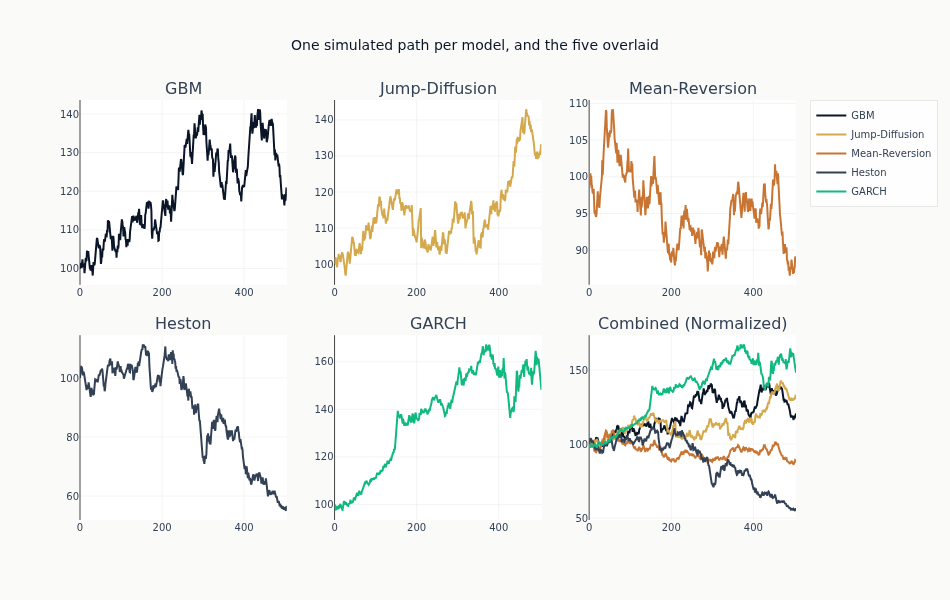

In [23]:
# Create comparison plot
fig = make_subplots(
    rows=2,
    cols=3,
    subplot_titles=list(all_models.keys()) + ["Combined (Normalized)"],
    vertical_spacing=0.12,
)

colors = [COLORS["blue"], COLORS["amber"], COLORS["copper"], COLORS["neutral"], COLORS["positive"]]

# Individual plots (no legend - subplot titles identify each)
for idx, (name, prices) in enumerate(all_models.items()):
    row, col = (idx // 3) + 1, (idx % 3) + 1
    fig.add_trace(
        go.Scatter(
            y=prices, mode="lines", name=name, line=dict(color=colors[idx]), showlegend=False
        ),
        row=row,
        col=col,
    )

# Combined normalized plot (with legend for comparison)
for idx, (name, prices) in enumerate(all_models.items()):
    normalized = 100 * prices / prices[0]
    fig.add_trace(
        go.Scatter(y=normalized, mode="lines", name=name, line=dict(color=colors[idx])),
        row=2,
        col=3,
    )

fig.update_layout(
    title_text="One simulated path per model, and the five overlaid",
    height=600,
    width=950,
)
show_plotly_with_alt(
    fig,
    "Six panels: one simulated price path for each of GBM, jump-diffusion, "
    "mean-reversion, Heston and GARCH, and a sixth panel overlaying all five "
    "rebased to 100 at the start.",
)

### Normalized Price Paths (Grayscale-Compatible)

A matplotlib companion to the plotly grid above, using distinct line styles
that remain distinguishable in grayscale print.

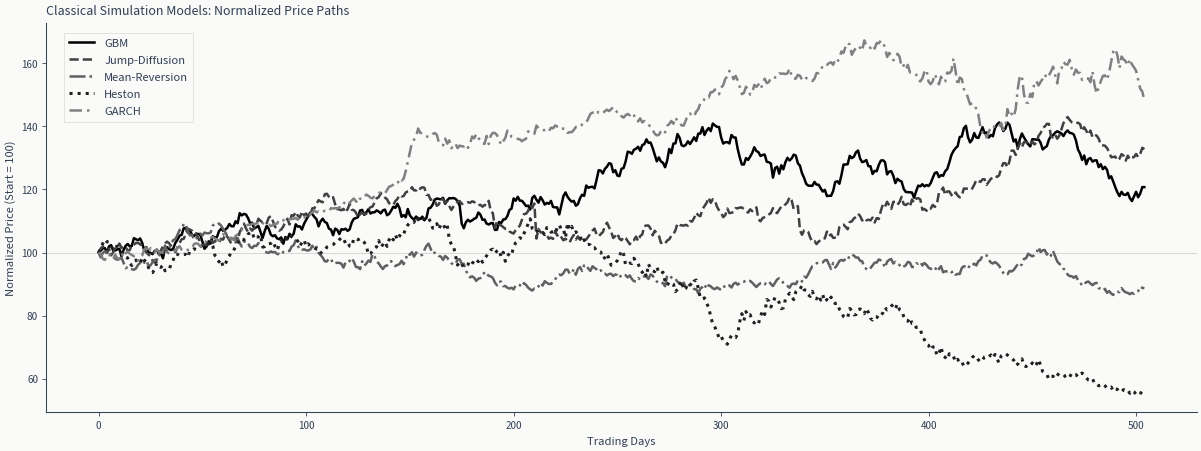

In [24]:
# Line styles for grayscale compatibility - varied grays + distinct patterns
LINE_STYLES = [
    {"linestyle": "-", "linewidth": 1.8, "color": "black"},  # GBM: solid black
    {"linestyle": "--", "linewidth": 1.8, "color": "#404040"},  # Jump-Diffusion: dashed dark gray
    {
        "linestyle": "-.",
        "linewidth": 1.8,
        "color": "#606060",
    },  # Mean-Reversion: dash-dot medium gray
    {"linestyle": ":", "linewidth": 2.2, "color": "#202020"},  # Heston: dotted near-black (thicker)
    {
        "linestyle": (0, (5, 2, 1, 2)),
        "linewidth": 1.8,
        "color": "#808080",
    },  # GARCH: long-dash-dot gray
]

# Built and styled in one cell so the inline backend cannot flush a
# half-constructed figure.
fig, ax = plt.subplots(figsize=(12, 4.5))

# Plot each model normalized to 100
for idx, (name, prices) in enumerate(all_models.items()):
    normalized = 100 * prices / prices[0]
    ax.plot(normalized, label=name, **LINE_STYLES[idx])

# Styling
ax.set_xlabel("Trading Days")
ax.set_ylabel("Normalized Price (Start = 100)")
ax.set_title("Classical Simulation Models: Normalized Price Paths")

# Legend outside plot area to avoid overlap
ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    frameon=True,
    fancybox=False,
    edgecolor="lightgray",
    fontsize=9,
)

# Add horizontal reference line at 100
ax.axhline(y=100, color="gray", linewidth=0.5, linestyle="-", alpha=0.4)

# Despine (seaborn style)
sns.despine(ax=ax)

show_with_alt(
    fig,
    "Five simulated price paths rebased to 100, drawn in distinct line styles "
    "so they stay separable in grayscale, with a reference line at the starting "
    "level of 100.",
)

These are five single realizations, one per model, and a picture of five
paths cannot separate a model's properties from the draw that produced them.
Two things it does show are structural rather than incidental: the
jump-diffusion panel contains discontinuities that no diffusion path can
produce, and the mean-reversion panel stays inside a band around its
equilibrium while the others wander. Everything else — which path looks
calmest, which drew the deepest drawdown — is a property of the draw. The
next section measures the model properties across many draws instead.

## Model Statistics Comparison

Each model is simulated `N_PATHS` times so the comparison describes the
**model** rather than one path. The sample excess kurtosis of a Gaussian
series of length `N_STEPS` has a standard error of $\sqrt{24/T}$, which at
this path length is large relative to the gaps between several of these
models, so an ordering read off one path per model is mostly noise. The cell
below prints it alongside GBM's measured spread.

The models are also **not** run at a common volatility: `GBM_SIGMA` and
$\sqrt{\texttt{HESTON\_THETA}}$ set one level, `MR_SIGMA` and `JD_SIGMA`
another, and GARCH inherits whatever the SPY fit implies. The volatility
column therefore reports the input, not a finding, and drawdown depth is not
comparable across rows for the same reason. Excess kurtosis and skewness are
the columns that describe the models, because no parameter sets them
directly.

In [25]:
def compute_model_stats(prices: np.ndarray, name: str) -> dict:
    """Compute key statistics for a price path using log-returns."""
    log_returns = np.diff(np.log(prices))
    return {
        "model": name,
        "annual_return": log_returns.mean() * 252,
        "annual_volatility": log_returns.std() * np.sqrt(252),
        "skewness": skew(log_returns),
        "excess_kurtosis": kurtosis(log_returns, fisher=True, bias=False),
        "max_drawdown": np.min(prices / np.maximum.accumulate(prices) - 1),
    }

### Simulating a Population of Paths

`simulate_path_population` re-runs each generator `N_PATHS` times from
independent child streams of the `model_paths` seed, so the paths are
independent of each other and of the illustrative paths plotted above.

In [26]:
def simulate_path_population(n_paths: int) -> dict[str, list[np.ndarray]]:
    """Simulate *n_paths* independent price paths for each parametric model."""
    seeds = _SEED_SEQUENCES["model_paths"].spawn(5)
    draw = {
        name: [np.random.default_rng(c) for c in seq.spawn(n_paths)]
        for name, seq in zip(all_models, seeds, strict=True)
    }

    populations: dict[str, list[np.ndarray]] = {}
    populations["GBM"] = [
        simulate_gbm(n_steps=N_STEPS, mu=GBM_MU, sigma=GBM_SIGMA, rng=r) for r in draw["GBM"]
    ]
    populations["Jump-Diffusion"] = [
        simulate_jump_diffusion(
            n_steps=N_STEPS,
            mu=JD_MU,
            sigma=JD_SIGMA,
            lambda_=JD_LAMBDA,
            mu_jump=JD_MU_JUMP,
            sigma_jump=JD_SIGMA_JUMP,
            rng=r,
        )
        for r in draw["Jump-Diffusion"]
    ]
    populations["Mean-Reversion"] = [
        simulate_mean_reversion_exact(
            n_steps=N_STEPS,
            kappa=MR_KAPPA,
            theta=np.log(MR_EQUILIBRIUM),
            sigma=MR_SIGMA,
            rng=r,
        )
        for r in draw["Mean-Reversion"]
    ]
    populations["Heston"] = [
        simulate_heston(
            n_steps=N_STEPS,
            mu=HESTON_MU,
            v0=HESTON_THETA,
            kappa=HESTON_KAPPA,
            theta=HESTON_THETA,
            xi=HESTON_XI,
            rho=HESTON_RHO,
            rng=r,
        )[0]
        for r in draw["Heston"]
    ]
    populations["GARCH"] = [
        100
        * np.exp(
            np.cumsum(
                np.insert(
                    simulate_garch(
                        n_steps=N_STEPS,
                        mu=mu_fit,
                        omega=omega_fit,
                        alpha=alpha_fit,
                        beta=beta_fit,
                        rng=r,
                    )[0]
                    / 100,
                    0,
                    0,
                )
            )
        )
        for r in draw["GARCH"]
    ]
    return populations


path_populations = simulate_path_population(N_PATHS)
assert all(len(v) == N_PATHS for v in path_populations.values())

stats_df = pl.DataFrame(
    [compute_model_stats(path, name) for name, paths in path_populations.items() for path in paths]
)


def summarize(column: str) -> pl.DataFrame:
    """Median and 5th-95th percentile range of *column* by model."""
    return stats_df.group_by("model", maintain_order=True).agg(
        pl.col(column).median().alias("median"),
        pl.col(column).quantile(0.05).alias("p05"),
        pl.col(column).quantile(0.95).alias("p95"),
    )


print(f"Gaussian excess-kurtosis standard error at T={N_STEPS}: {np.sqrt(24 / N_STEPS):.3f}")
print("Volatility each model was parameterized at (annualized):")
print(
    f"  GBM {GBM_SIGMA:.2f}, Heston {np.sqrt(HESTON_THETA):.2f}, "
    f"mean-reversion {MR_SIGMA:.2f}, jump-diffusion diffusion part {JD_SIGMA:.2f}"
)

print(f"\nExcess kurtosis across {N_PATHS} paths per model:")
print(summarize("excess_kurtosis"))
print(f"\nSkewness across {N_PATHS} paths per model:")
print(summarize("skewness"))

Gaussian excess-kurtosis standard error at T=504: 0.218
Volatility each model was parameterized at (annualized):
  GBM 0.20, Heston 0.20, mean-reversion 0.15, jump-diffusion diffusion part 0.15

Excess kurtosis across 200 paths per model:
shape: (5, 4)
┌────────────────┬───────────┬───────────┬───────────┐
│ model          ┆ median    ┆ p05       ┆ p95       │
│ ---            ┆ ---       ┆ ---       ┆ ---       │
│ str            ┆ f64       ┆ f64       ┆ f64       │
╞════════════════╪═══════════╪═══════════╪═══════════╡
│ GBM            ┆ -0.036059 ┆ -0.340742 ┆ 0.318238  │
│ Jump-Diffusion ┆ 12.76383  ┆ 2.60252   ┆ 33.850432 │
│ Mean-Reversion ┆ -0.046515 ┆ -0.329797 ┆ 0.397193  │
│ Heston         ┆ 0.40584   ┆ -0.028395 ┆ 1.26376   │
│ GARCH          ┆ 1.101162  ┆ 0.111331  ┆ 5.823677  │
└────────────────┴───────────┴───────────┴───────────┘

Skewness across 200 paths per model:
shape: (5, 4)
┌────────────────┬───────────┬───────────┬───────────┐
│ model          ┆ median    ┆ p05 

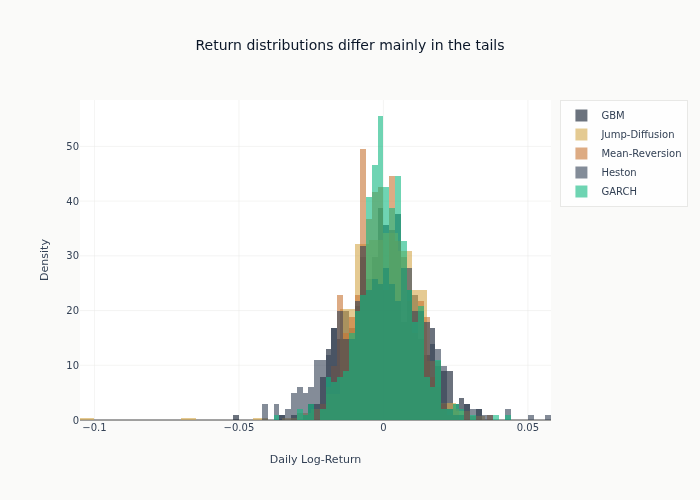

In [27]:
# Return distribution comparison
fig = go.Figure()

for idx, (name, prices) in enumerate(all_models.items()):
    log_returns = np.diff(np.log(prices))
    fig.add_trace(
        go.Histogram(
            x=log_returns,
            name=name,
            opacity=0.6,
            nbinsx=50,
            histnorm="probability density",
            marker_color=colors[idx],
        )
    )

fig.update_layout(
    title="Return distributions differ mainly in the tails",
    xaxis_title="Daily Log-Return",
    yaxis_title="Density",
    barmode="overlay",
)
show_plotly_with_alt(
    fig,
    "Overlaid density histograms of daily log-returns from the five simulated "
    "paths; the bodies largely coincide while the jump-diffusion series extends "
    "furthest into the negative tail.",
)

### Which Models Separate

Rather than reading an ordering off the medians, compare each model's excess
kurtosis against GBM's. GBM is the null here: its log-returns are Gaussian by
construction, so its spread over `N_PATHS` paths is the sampling noise of the
statistic at this path length, and a model separates only if its own spread
sits clear of that.

In [28]:
kurt_by_model = {
    name: stats_df.filter(pl.col("model") == name)["excess_kurtosis"].to_numpy()
    for name in path_populations
}
gbm_p95 = np.percentile(kurt_by_model["GBM"], 95)

print(f"GBM excess kurtosis, 5th-95th percentile over {N_PATHS} paths: ")
print(f"  [{np.percentile(kurt_by_model['GBM'], 5):.3f}, {gbm_p95:.3f}]")
print("\nShare of paths above the GBM 95th percentile:")
for name, values in kurt_by_model.items():
    share = float((values > gbm_p95).mean())
    print(f"  {name:15s} median {np.median(values):7.3f}   above GBM p95: {share:6.1%}")


def dominance(a: str, b: str) -> float:
    """Share of (a, b) path pairs in which *a* has the higher excess kurtosis."""
    return float((kurt_by_model[a][:, None] > kurt_by_model[b][None, :]).mean())


print("\nPairwise dominance, P(row path exceeds column path):")
fat_tailed = ["Jump-Diffusion", "GARCH", "Heston"]
for a in fat_tailed:
    row = "  ".join(f"{dominance(a, b):.2f}" if a != b else "  - " for b in fat_tailed)
    print(f"  {a:15s} {row}")

GBM excess kurtosis, 5th-95th percentile over 200 paths: 
  [-0.341, 0.318]

Share of paths above the GBM 95th percentile:
  GBM             median  -0.036   above GBM p95:   5.0%
  Jump-Diffusion  median  12.764   above GBM p95:  99.5%
  Mean-Reversion  median  -0.047   above GBM p95:   7.5%
  Heston          median   0.406   above GBM p95:  59.5%
  GARCH           median   1.101   above GBM p95:  86.0%

Pairwise dominance, P(row path exceeds column path):
  Jump-Diffusion    -   0.95  0.99
  GARCH           0.05    -   0.78
  Heston          0.01  0.22    - 


### Volatility Clustering in the Same Populations

Fat tails and volatility clustering are separate properties, and so far only
the first has been measured. Summarize clustering the same way the bootstrap
section does — the sum of the autocorrelations of squared returns over the
first `n_lags` lags — and read it against GBM, whose returns are independent
by construction and whose spread is therefore the null.

In [29]:
CLUSTER_LAGS = 20


def clustering_statistic(prices: np.ndarray) -> float:
    """Summed autocorrelation of squared log-returns over the first lags."""
    return float(acf(np.diff(np.log(prices)) ** 2, nlags=CLUSTER_LAGS, fft=True)[1:].sum())


clustering = {
    name: np.array([clustering_statistic(path) for path in paths])
    for name, paths in path_populations.items()
}
clustering_gbm_p95 = np.percentile(clustering["GBM"], 95)

# SPY must be measured over the same window length. The statistic sums 20
# autocorrelation estimates, each biased and noisy in proportion to 1/T, so its
# value on 5030 returns is not comparable with a simulated path of N_STEPS.
spy_windows = np.array(
    [
        clustering_statistic(spy_close[i : i + N_STEPS + 1])
        for i in range(0, len(spy_close) - N_STEPS, N_STEPS)
    ]
)
spy_clustering_median = float(np.median(spy_windows))

print(f"Summed ACF of squared returns over lags 1-{CLUSTER_LAGS}, {N_PATHS} paths per model")
print(f"SPY, whole history ({len(spy_close) - 1} returns): {clustering_statistic(spy_close):.2f}")
print(
    f"SPY, {len(spy_windows)} non-overlapping {N_STEPS}-day windows: "
    f"median {spy_clustering_median:.2f}, "
    f"range {spy_windows.min():.2f} to {spy_windows.max():.2f}\n"
)
for name, values in clustering.items():
    above_null = float((values > clustering_gbm_p95).mean())
    above_spy = float((values > spy_clustering_median).mean())
    print(
        f"  {name:15s} median {np.median(values):6.3f}   "
        f"above GBM p95: {above_null:6.1%}   above SPY median: {above_spy:6.1%}"
    )

Summed ACF of squared returns over lags 1-20, 200 paths per model
SPY, whole history (5030 returns): 4.63
SPY, 9 non-overlapping 504-day windows: median 2.21, range 0.52 to 5.02

  GBM             median -0.051   above GBM p95:   5.0%   above SPY median:   0.0%
  Jump-Diffusion  median -0.071   above GBM p95:   6.5%   above SPY median:   0.0%
  Mean-Reversion  median -0.050   above GBM p95:   9.0%   above SPY median:   0.0%
  Heston          median  0.812   above GBM p95:  86.5%   above SPY median:   4.5%
  GARCH           median  2.566   above GBM p95: 100.0%   above SPY median:  62.5%


**What the comparison establishes.** Three models generate excess kurtosis and
they order the same way in every pairwise comparison: jump-diffusion above
GARCH above Heston. Jump-diffusion is the clearest, exceeding GBM's 95th
percentile on nearly every path, which is what an explicit jump component is
for. GARCH exceeds Heston on close to three quarters of path pairs, so the
ordering between those two is real even though their ranges overlap and a
single path from each would not have shown it.

Mean-reversion is indistinguishable from GBM on kurtosis: it clears GBM's 95th
percentile at about the rate chance alone would produce. Its visibly narrower
price range comes from the lower volatility it was parameterized with and from
the pull toward equilibrium, neither of which is a tail property.

On clustering the split is different and cleaner. GBM, mean-reversion and
jump-diffusion all sit at the GBM null rate: jumps arrive independently, so
adding them fattens the tails without making one volatile day predict the
next. Heston and GARCH both clear the null on the large majority of paths,
which is what a mean-reverting variance process and a variance recursion are
for, and GARCH does so on every path and at roughly three times Heston's
median.

The comparison against SPY needs the same window length on both sides. The
statistic sums twenty autocorrelation estimates, and both the bias and the
variance of each estimate depend on the sample length, so a value computed on
SPY's whole history and a value computed on a simulated path of `N_STEPS` are
not two measurements of the same quantity. Equal-length windows make them
comparable; they do not make either one a better estimate.

Measured that way, GARCH's distribution is centered slightly **above** SPY's
median rather than short of it, and Heston's sits below. Read the nine SPY
windows before reading that as a stable ranking: they span most of the range
the models occupy, and they differ in the volatility regimes they cover as
well as in sampling noise, so neither the spread across windows nor the gap to
the full-history value has a single cause the notebook has isolated.

So the two properties order the models differently. Jump-diffusion has the
heaviest tails and no clustering at all; GARCH has the most clustering and the
second-heaviest tails; Heston has both, more weakly than GARCH on each.

For risk work: GBM and mean-reversion put no more weight in the tails than a
Gaussian, so VaR and ES computed from them understate tail loss by
construction. The magnitudes separating the other three are large enough to
matter — the jump model's median excess kurtosis is an order of magnitude
above the other two — so the choice among them is not a rounding difference.

---
# Part 3: Bootstrap Methods

Bootstrap methods resample historical data rather than assuming a parametric
model. They preserve the **empirical distribution** exactly, including fat tails.

| Method | Block Size | Preserves Autocorrelation | Best For |
|--------|-----------|--------------------------|----------|
| **IID Bootstrap** | 1 | No | i.i.d. assumption OK |
| **Block Bootstrap** | Fixed | Yes (within blocks) | Time series |
| **Stationary Bootstrap** | Random | Yes (smoother) | Financial returns |

### Key Trade-off

- **Parametric**: Can generate scenarios *beyond* historical range
- **Bootstrap**: Preserves empirical distribution *exactly* but limited to observed extremes

### Consistency Note

We bootstrap **log-returns** to match the parametric models above.

## Load Real Data for Bootstrap

In [30]:
# Compute log-returns (consistent with parametric models)
spy_log_returns = np.diff(np.log(spy_close))

print(f"SPY log-returns: {len(spy_log_returns)} observations")
print(f"Mean: {spy_log_returns.mean():.6f}")
print(f"Std: {spy_log_returns.std():.4f}")
print(f"Skewness: {skew(spy_log_returns):.4f}")
print(
    f"Excess kurtosis: {kurtosis(spy_log_returns, fisher=True, bias=False):.4f} (Fisher, Gaussian=0)"
)

SPY log-returns: 5030 observations
Mean: 0.000408
Std: 0.0122
Skewness: -0.3042
Excess kurtosis: 14.3458 (Fisher, Gaussian=0)


## IID Bootstrap

The simplest resampling method: draw individual returns **with replacement**.

### Algorithm

```
For each bootstrap sample of length T:
    For t = 1 to T:
        Draw index i uniformly from {1, ..., N}
        Set r*_t = r_i  (original return i)
    Return r* = (r*_1, ..., r*_T)
```

### Properties

- **Preserves marginal distribution**: Same histogram as original
- **Destroys autocorrelation**: Each draw is independent
- **Fast and simple**: No tuning parameters

In [31]:
def iid_bootstrap(
    data: np.ndarray,
    n_samples: int,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """
    Generate IID bootstrap sample.

    Parameters
    ----------
    data : np.ndarray
        Original data
    n_samples : int
        Length of bootstrap sample
    rng : np.random.Generator, optional
        Random number generator

    Returns
    -------
    np.ndarray
        Bootstrap sample
    """
    if rng is None:
        rng = np.random.default_rng()
    indices = rng.choice(len(data), size=n_samples, replace=True)
    return data[indices]

Draw one IID bootstrap sample the same length as the original series and
compare its moments with the original's.

In [32]:
iid_sample = iid_bootstrap(spy_log_returns, len(spy_log_returns), rng=stream("iid_bootstrap"))

print("IID Bootstrap vs Original (log-returns):")
print(f"  Mean: {iid_sample.mean():.6f} vs {spy_log_returns.mean():.6f}")
print(f"  Std: {iid_sample.std():.4f} vs {spy_log_returns.std():.4f}")
print(f"  Skew: {skew(iid_sample):.4f} vs {skew(spy_log_returns):.4f}")

IID Bootstrap vs Original (log-returns):
  Mean: 0.000761 vs 0.000408
  Std: 0.0116 vs 0.0122
  Skew: -0.3720 vs -0.3042


### Library Usage: IID Bootstrap

In [33]:
bs = IIDBootstrap(spy_log_returns, seed=SEED)
means = [data[0].mean() for data, _ in bs.bootstrap(100)]
print(f"arch IIDBootstrap (100 samples): mean of means = {np.mean(means):.6f}")

arch IIDBootstrap (100 samples): mean of means = 0.000431


## Block Bootstrap

Resample **contiguous blocks** of fixed length to preserve local dependence.

### Algorithm (Moving Block Bootstrap)

```
Choose block length b
For each bootstrap sample of length T:
    While sample length < T:
        Draw start index i uniformly from {1, ..., N-b+1}
        Append block (r_i, r_{i+1}, ..., r_{i+b-1})
    Trim to length T
```

### Block Length Selection

- Rule of thumb: $b \approx T^{1/3}$
- Financial: ~22 days (one month) is common
- Optimal: Cross-validation on out-of-sample statistics

In [34]:
def block_bootstrap(
    data: np.ndarray,
    block_size: int,
    n_samples: int,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """
    Generate moving block bootstrap sample.

    Parameters
    ----------
    data : np.ndarray
        Original data
    block_size : int
        Fixed block length
    n_samples : int
        Length of bootstrap sample
    rng : np.random.Generator, optional
        Random number generator

    Returns
    -------
    np.ndarray
        Bootstrap sample
    """
    if rng is None:
        rng = np.random.default_rng()

    n = len(data)
    result = []

    while len(result) < n_samples:
        start = rng.integers(0, n - block_size + 1)
        block = data[start : start + block_size]
        result.extend(block)

    return np.array(result[:n_samples])

Use 22-day blocks, roughly one trading month.

In [35]:
block_size = 22
block_sample = block_bootstrap(
    spy_log_returns, block_size, len(spy_log_returns), rng=stream("block_bootstrap")
)

print(f"Block Bootstrap (block_size={block_size}) vs Original:")
print(f"  Mean: {block_sample.mean():.6f} vs {spy_log_returns.mean():.6f}")
print(f"  Std: {block_sample.std():.4f} vs {spy_log_returns.std():.4f}")

Block Bootstrap (block_size=22) vs Original:
  Mean: 0.000419 vs 0.000408
  Std: 0.0141 vs 0.0122


### Library Usage: Block Bootstrap

In [36]:
bs = MovingBlockBootstrap(block_size, spy_log_returns, seed=SEED)
means = [data[0].mean() for data, _ in bs.bootstrap(100)]
print(f"arch MovingBlockBootstrap (100 samples): mean of means = {np.mean(means):.6f}")

arch MovingBlockBootstrap (100 samples): mean of means = 0.000402


## Stationary Bootstrap

Uses **random block lengths** from a geometric distribution, eliminating
artificial block boundaries.

### Algorithm (Politis & Romano 1994)

```
Choose expected block length b
For each bootstrap sample of length T:
    Set t = 0
    While t < T:
        Draw start index i uniformly from {1, ..., N}
        Draw block length L from Geometric(1/b)
        Append (r_i, r_{i+1}, ..., r_{i+L-1}) with wrap-around
        t = t + L
    Trim to length T
```

### Why "Stationary"?

With random block lengths, the bootstrap distribution is **stationary** -
each position in the sample has the same marginal distribution.

In [37]:
def stationary_bootstrap(
    data: np.ndarray,
    expected_block_size: float,
    n_samples: int,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """
    Generate stationary bootstrap sample.

    Parameters
    ----------
    data : np.ndarray
        Original data
    expected_block_size : float
        Expected block length (geometric distribution parameter)
    n_samples : int
        Length of bootstrap sample
    rng : np.random.Generator, optional
        Random number generator

    Returns
    -------
    np.ndarray
        Bootstrap sample
    """
    if rng is None:
        rng = np.random.default_rng()

    n = len(data)
    p = 1.0 / expected_block_size  # Probability of ending block
    result = []

    while len(result) < n_samples:
        pos = rng.integers(0, n)

        while len(result) < n_samples:
            result.append(data[pos])
            pos = (pos + 1) % n  # Wrap around

            if rng.random() < p:
                break

    return np.array(result[:n_samples])

Use the same expected block length so the two block methods differ only in
whether the length is fixed or random.

In [38]:
stat_sample = stationary_bootstrap(
    spy_log_returns, block_size, len(spy_log_returns), rng=stream("stationary_bootstrap")
)

print(f"Stationary Bootstrap (expected block={block_size}) vs Original:")
print(f"  Mean: {stat_sample.mean():.6f} vs {spy_log_returns.mean():.6f}")
print(f"  Std: {stat_sample.std():.4f} vs {spy_log_returns.std():.4f}")

Stationary Bootstrap (expected block=22) vs Original:
  Mean: 0.000312 vs 0.000408
  Std: 0.0131 vs 0.0122


### Library Usage: Stationary Bootstrap

In [39]:
bs = StationaryBootstrap(block_size, spy_log_returns, seed=SEED)
means = [data[0].mean() for data, _ in bs.bootstrap(100)]
print(f"arch StationaryBootstrap (100 samples): mean of means = {np.mean(means):.6f}")

arch StationaryBootstrap (100 samples): mean of means = 0.000405


## Bootstrap Method Comparison

In [40]:
# Collect bootstrap samples
bootstrap_samples = {
    "Original": spy_log_returns,
    "IID": iid_sample,
    "Block": block_sample,
    "Stationary": stat_sample,
}

# Compare moments
bootstrap_stats = []
for name, sample in bootstrap_samples.items():
    bootstrap_stats.append(
        {
            "method": name,
            "mean": sample.mean(),
            "std": sample.std(),
            "skew": skew(sample),
            "excess_kurtosis": kurtosis(sample, fisher=True, bias=False),
        }
    )

pl.DataFrame(bootstrap_stats)

method,mean,std,skew,excess_kurtosis
str,f64,f64,f64,f64
"""Original""",0.000408,0.01222,-0.304239,14.345821
"""IID""",0.000761,0.011638,-0.372023,12.593651
"""Block""",0.000419,0.014085,-0.12023,16.474232
"""Stationary""",0.000312,0.013077,-0.306528,12.933027


## Autocorrelation Preservation

The key difference between bootstrap methods is how they handle **temporal
dependence**. We measure this via autocorrelation of **squared returns**
(signature of volatility clustering).

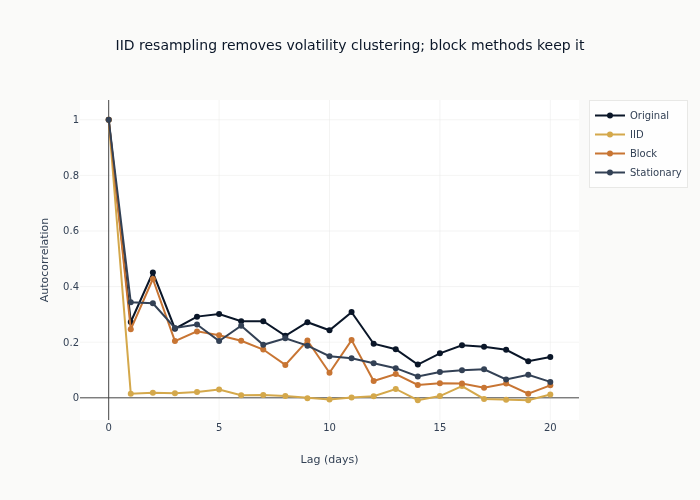

In [41]:
# Compute ACF for squared returns
n_lags = 20
fig = go.Figure()

bootstrap_colors = [COLORS["blue"], COLORS["amber"], COLORS["copper"], COLORS["neutral"]]

for idx, (name, sample) in enumerate(bootstrap_samples.items()):
    squared = sample**2
    acf_values = acf(squared, nlags=n_lags, fft=True)
    fig.add_trace(
        go.Scatter(
            x=list(range(n_lags + 1)),
            y=acf_values,
            mode="lines+markers",
            name=name,
            line=dict(color=bootstrap_colors[idx]),
        )
    )

fig.update_layout(
    title="IID resampling removes volatility clustering; block methods keep it",
    xaxis_title="Lag (days)",
    yaxis_title="Autocorrelation",
)
show_plotly_with_alt(
    fig,
    "Autocorrelation of squared returns against lag for the original SPY series "
    "and three bootstrap resamples; all four start at one by definition at lag "
    "zero, after which the IID resample drops to zero while the block and "
    "stationary resamples stay close to the original.",
)

### How Much Dependence Each Method Retains

The ACF curves above come from one resample each, and one resample cannot rank
two methods that differ only in whether the block length is fixed or random.
Summarize each resample by the sum of its squared-return autocorrelations over
the first `n_lags` lags, divided by the same sum for the original series, and
repeat it `N_BOOTSTRAP_REPLICATES` times per method. A value of one means the
resample carries as much volatility clustering as SPY; zero means none.

In [42]:
original_dependence = acf(spy_log_returns**2, nlags=n_lags, fft=True)[1:].sum()

resamplers = {
    "IID": lambda rng: iid_bootstrap(spy_log_returns, len(spy_log_returns), rng=rng),
    "Block": lambda rng: block_bootstrap(
        spy_log_returns, block_size, len(spy_log_returns), rng=rng
    ),
    "Stationary": lambda rng: stationary_bootstrap(
        spy_log_returns, block_size, len(spy_log_returns), rng=rng
    ),
}

method_seeds = dict(
    zip(resamplers, _SEED_SEQUENCES["bootstrap_replicates"].spawn(len(resamplers)), strict=True)
)

retention = {}
for method, resample in resamplers.items():
    generators = [
        np.random.default_rng(child) for child in method_seeds[method].spawn(N_BOOTSTRAP_REPLICATES)
    ]
    retention[method] = np.array(
        [
            acf(resample(rng) ** 2, nlags=n_lags, fft=True)[1:].sum() / original_dependence
            for rng in generators
        ]
    )

print(f"Dependence retained, {N_BOOTSTRAP_REPLICATES} replicates per method")
print(f"(sum of ACF of squared returns over lags 1-{n_lags}, as a share of SPY's)")
for method, values in retention.items():
    print(
        f"  {method:11s} median {np.median(values):6.3f}  "
        f"[{np.percentile(values, 5):6.3f}, {np.percentile(values, 95):6.3f}]"
    )

stationary_beats_block = float(
    (retention["Stationary"][:, None] > retention["Block"][None, :]).mean()
)
print(
    f"\nP(a stationary replicate retains more than a block replicate) = "
    f"{stationary_beats_block:.2f}"
)

Dependence retained, 200 replicates per method
(sum of ACF of squared returns over lags 1-20, as a share of SPY's)
  IID         median -0.001  [-0.019,  0.022]
  Block       median  0.564  [ 0.408,  0.715]
  Stationary  median  0.651  [ 0.381,  0.862]

P(a stationary replicate retains more than a block replicate) = 0.64


### Bootstrap Key Takeaways

1. **IID bootstrap** reproduces the marginal distribution — the same histogram,
   the same fat tails — and retains essentially none of the volatility
   clustering, which is what resampling one observation at a time implies.
2. **Block and stationary bootstrap** both retain roughly two thirds of SPY's
   squared-return dependence at a 22-day block length. Neither recovers all of
   it: dependence that spans a block boundary is destroyed whatever the block
   length, and lengthening blocks to keep more of it leaves fewer distinct
   blocks to resample.
3. **Random block lengths help, modestly.** The stationary bootstrap retains
   more than the moving block bootstrap in the majority of paired draws, but
   the two distributions overlap heavily, so the advantage shows up across
   replicates and is not something a single resample would establish.

For financial returns with volatility clustering, either block method is a
reasonable default and the choice between them matters less than the block
length.

---
# Part 4: Model Comparison Summary

## What Each Method Captures

Fat tails and volatility clustering are separate properties and are measured
separately above: excess kurtosis across `N_PATHS` paths for the parametric
models, retained squared-return autocorrelation across
`N_BOOTSTRAP_REPLICATES` replicates for the resamplers. "Beyond history" asks
whether the method can emit a value larger than any it was given.

| Method | Excess kurtosis above Gaussian | Volatility clustering | Beyond history |
|--------|-------------------------------|-----------------------|----------------|
| GBM | No, by construction | None; this row is the null both columns are read against | Yes |
| Jump-Diffusion | Yes, the heaviest measured here | None; jumps arrive independently | Yes |
| Mean-Reversion | No | None; its dependence is negative autocorrelation in returns, not in squared returns | Yes |
| Heston | Yes, below GARCH | Yes, on most paths, from mean-reverting variance | Yes |
| GARCH | Yes, above Heston | Yes, on every path and the strongest measured | Yes |
| IID Bootstrap | Inherits the sample's | None retained | No |
| Block Bootstrap | Inherits the sample's | About two thirds retained | No |
| Stationary Bootstrap | Inherits the sample's | About two thirds retained, slightly more than fixed blocks | No |

## Key Takeaways

1. **Parametric models** can emit values beyond anything in the historical
   sample, which is what makes them usable for stress scenarios, but every
   property they exhibit is one that was chosen or fitted.
2. **Bootstrap methods** reproduce the empirical marginal distribution, fat
   tails included, without any distributional assumption, and cannot produce a
   return larger than the largest one observed.
3. **Heston and GARCH capture both stylized facts; the jump model captures
   only one.** Measured against GBM as the null, jump-diffusion has the
   heaviest tails and no volatility clustering whatever, while Heston and
   GARCH clear the null on both properties, GARCH more strongly on each. On
   clustering, compared against SPY over equal-length windows, GARCH is not
   short of the empirical level at all — its median sits above SPY's. Matching
   one statistic is not matching the series, which is the argument for the
   validation protocol the rest of the chapter builds.
4. **Drift compensation** (jump-diffusion) and **full truncation** (Heston) are
   implementation details that change what is simulated, not stylistic choices;
   without the compensator the requested drift is not the realized drift, and
   without truncation the variance recursion can go negative.
5. **Fitting GARCH by maximum likelihood** replaces two chosen numbers with two
   estimated ones, which is a different claim from producing more realistic
   paths: persistence comes from the data, the level still has to be carried
   across explicitly, as the library comparison above shows.

**Next**: See [`01_timegan`](01_timegan.ipynb) for the first learned generative model, which uses
adversarial training to capture temporal dynamics that classical models miss.

**Book**: Chapter 5, Section 5.4 covers the generative model taxonomy and explains
why learned models complement (rather than replace) classical simulation.